# Manual Pipeline
- I made a mistake earlier. Should not have skipepd straight to building a pipeline.
- Verify the prior selection on a set of three stars first.
- Here we will do the first one.

---
- In this notebook:
    - Plot the stellar S-Ind data.
    - Run LSP on it.
    - Remove dominant mode.
    - Run LSP on residuals.
    - Flag aliases and window functions.
        - Aliases are harmonics of the dominant signal. For stars the dominant signal is probably $P_rot$
        - Window functions are regular due to observations ie daily, weekly, monthly etc.
    - Ignore these as bias.
    - Remaining peaks above FAP threshold are significant too.
    - Classify those significant peaks. (you alr have this from priors1)
    - Formulate priors.
    - GPR
    -Window analysis.
---
- Here will just do HD81809. 


In [25]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable


# Importing data
data = pd.read_csv(r"./Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)

# data = pd.read_csv(r"./Data/hd166_caii.txt", sep='\s',skip_blank_lines=True)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data["day"] = time_obj.jd 
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')

# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.8, valid_split=0.19):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

# Split the data
train_df, valid_df, test_df = split_df(data)


C:\Users\Joey\AppData\Local\Temp\ipykernel_66744\3791637440.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)


[ 295.77551755  324.9780378   338.84923492  417.6960396  1523.01143114
 2991.89819982 5007.60216022] {'peak_heights': array([0.10062945, 0.45093232, 0.18118007, 0.46867476, 0.17075122,
       1.        , 0.27014847])}
[0.03075379 0.03321164 0.03925835 0.04781179]


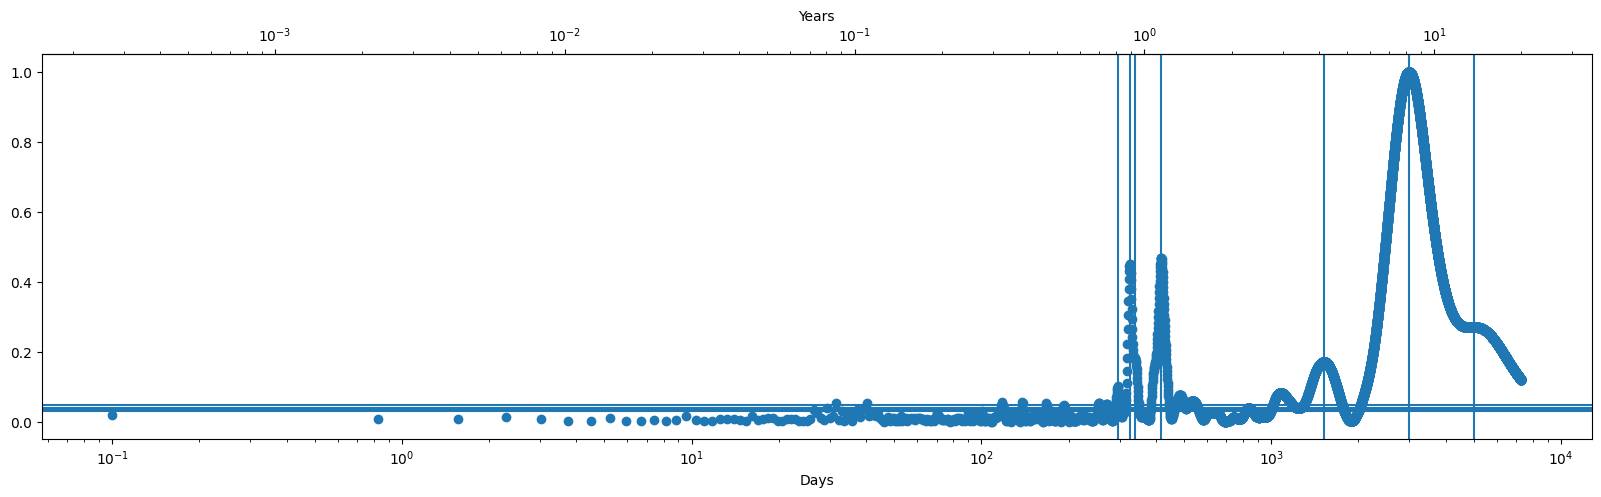

The best period is 2991.898199819982 days


In [39]:
# Lomb scargle 
# Lomb-Scargle finds periodic signals in unevnly sampled time series.
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

# Define freq range
min_period = 0.1
max_period = 365*20 # now in days
n_periods = 10000
periods = np.linspace(min_period, max_period, n_periods)
freq = 1 / periods

ls = LombScargle(train_df['day'], train_df['sind'])
power = ls.power(freq)

# # Normalise the powers to frac of max to aid in peak finding
max_power = max(power)
power /= max_power

# noise = np.percentile(power, 75)
# print(max_power)

# FAPs of note
FAPs = np.array([10, 5, 1, 0.01]) / 100
power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
power_invFAPs /= max_power

noise = max(FAPs)

# Find the Lomb-Scargle peak
peaks, properties = find_peaks(power, height = noise) # peaks is an array of the indices of the input arrays with the peaks
peak_periods = periods[peaks]
print(peak_periods, properties)

# Things for calculating the FAP
N = len(train_df)
T = train_df['day'].max() - train_df['day'].min()
M = T * (1/min_period - 1/max_period)
# print(N,M)

# # FAPs of note
# FAPs = np.array([10, 5, 1, 0.01, 0.001]) / 100
# power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') / max_power
# power_invFAPs = invFAP(N = N, M = M, FAP = FAPs)
# power_invFAPs = 2 * power_invFAPs / (N - 1)  # convert HB units to standard
# power_invFAPs /= max_power
print(power_invFAPs)

# plot the thing
fig, ax = plt.subplots(1, figsize=(20, 5))
ax.set_xscale('log')
ax.scatter(periods, power)

for peak_period in peak_periods:
    ax.axvline(peak_period)
for power_invFAP in power_invFAPs:
    ax.axhline(power_invFAP)

ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365, lambda y: y * 365))
ax2.set_xlabel('Years')
ax.set_xlabel('Days')

plt.show()

# print the best period
best_period = periods[np.argmax(power)]
print(f"The best period is {best_period} days")


In [ ]:
# Now remove the peak prominence
# peaks, properties['peak_heights']
peaks = list(zip(peak_periods, properties['peak_heights']))
highest_idx = np.argmax(properties['peak_heights'])
dominant_period = peak_periods[highest_idx]




([(np.float64(295.7755175517552), np.float64(0.10062944595950198)),
  (np.float64(324.9780378037804), np.float64(0.4509323202242806)),
  (np.float64(338.84923492349236), np.float64(0.18118006959564523)),
  (np.float64(417.6960396039604), np.float64(0.4686747553839904)),
  (np.float64(1523.0114311431141), np.float64(0.17075122231918763)),
  (np.float64(2991.898199819982), np.float64(1.0)),
  (np.float64(5007.602160216022), np.float64(0.2701484667794363))],
 np.float64(2991.898199819982))